<a href="https://colab.research.google.com/github/abdoyanes/Point-Cloud-Data_analysis/blob/main/Budyko_WaterBalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AOI: GEE asset
Soil: OpenLandMap

Computing Budyko indices per LULC-Soil class...
Saved T9_Budyko_Indices_by_Class.csv (16 classes)
                     Combo  Aridity_PET_P  Evap_Index_ET_P  Runoff_Coef_alpha
         Cropland × Clayey          7.006            0.954              0.046
          Cropland × Loamy          8.685            0.783              0.217
 Permanent_Wetland × Loamy          9.310            0.531              0.469
Permanent_Wetland × Clayey          8.076            0.485              0.515
        Grassland × Clayey          7.731            0.386              0.614
            Urban × Clayey         10.906            0.303              0.697
         Grassland × Loamy          9.154            0.284              0.716
             Water × Loamy         16.912            0.281              0.719
             Urban × Loamy         13.268            0.266              0.734
  Barren_Bare_Soil × Loamy         18.187            0.248              0.752
 Barren_Ba

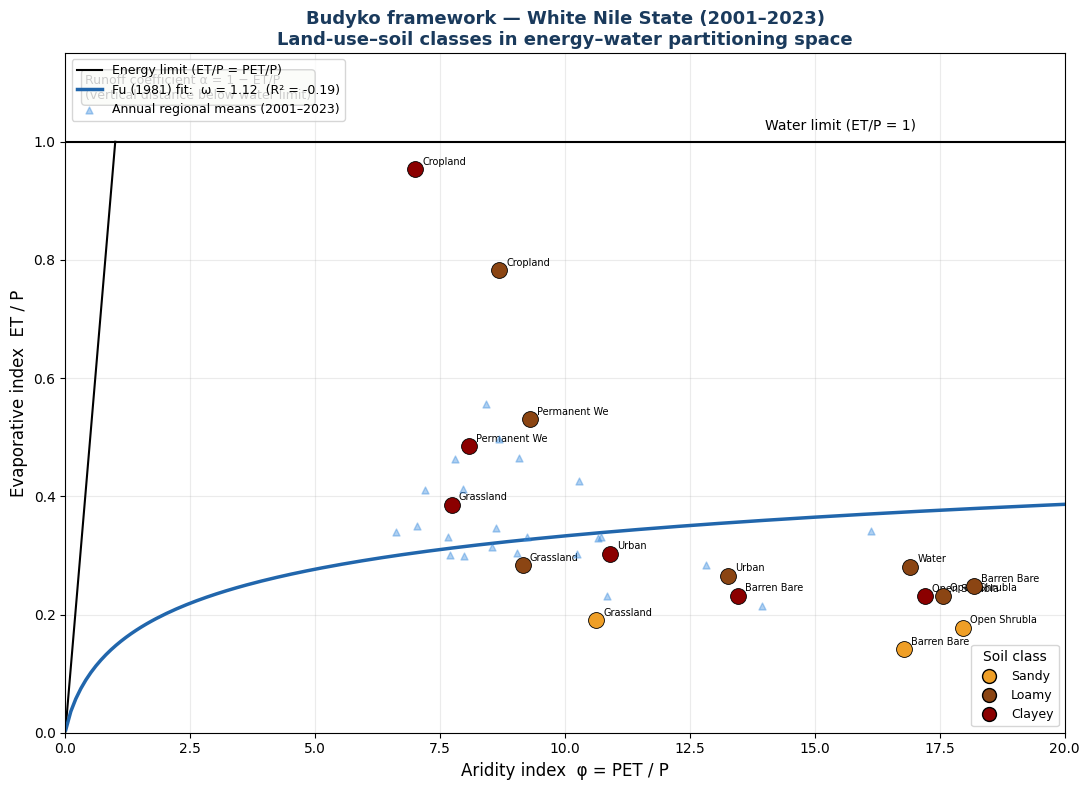

Saved F_Budyko_Framework.png
Export started: RunoffCoefficient_alpha.tif

BUDYKO ANALYSIS SUMMARY
  Fitted Fu parameter ω : 1.124  (R² = -0.190)
  Aridity range φ       : 7.01 – 18.19
  All classes water-limited (φ > 1): True

  Highest runoff coefficient (most water yield):
    Barren_Bare_Soil × Sandy: α = 0.858
  Lowest runoff coefficient (most consumptive):
    Cropland × Clayey: α = 0.046

  Outputs: T9, T10 CSVs + F_Budyko_Framework.png + RunoffCoefficient_alpha.tif


In [ ]:
# =============================================================================
# BUDYKO FRAMEWORK + WATER BALANCE + RUNOFF COEFFICIENT
# White Nile State, Sudan  |  Implements supervisor's revised methodology
#
# Computes, per LULC-Soil class and per year:
#   φ  = PET / P          (aridity / dryness index)
#   EI = ET  / P          (evaporative index)
#   ω                     (Fu 1981 parameter, fitted)
#   α  = R / P = 1 - ET/P (runoff coefficient, long-term)
#
# Produces: Budyko scatter plot, fitted Fu curve, per-class table,
#           annual Budyko trajectory, runoff-coefficient map export.
#
# Paste as a NEW Colab cell. Self-contained.
# =============================================================================

import ee, os, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')

# ── 0. Setup ─────────────────────────────────────────────────────────────────
try:
    ee.Number(1).getInfo()
except Exception:
    ee.Authenticate()
    ee.Initialize(project='evapotranspiration-495110')

OUTPUT_DIR = '/content/drive/MyDrive/ET_WhiteNile_Analysis'
os.makedirs(f'{OUTPUT_DIR}/tables', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots',  exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/geotiff', exist_ok=True)

START_YEAR, END_YEAR = 2001, 2023
START_DATE, END_DATE = f'{START_YEAR}-01-01', f'{END_YEAR}-12-31'
YEARS  = list(range(START_YEAR, END_YEAR + 1))
SCALE  = 500
COMP   = 46   # 8-day composites per year

LULC_CLASSES = {1:'Evergreen_Needleleaf_Forest',2:'Evergreen_Broadleaf_Forest',
    3:'Deciduous_Needleleaf_Forest',4:'Deciduous_Broadleaf_Forest',5:'Mixed_Forest',
    6:'Closed_Shrubland',7:'Open_Shrubland',8:'Woody_Savanna',9:'Savanna',
    10:'Grassland',11:'Permanent_Wetland',12:'Cropland',13:'Urban',
    14:'Cropland_Natural_Mosaic',16:'Barren_Bare_Soil',17:'Water'}
SOIL_CLASSES = {1:'Sandy',2:'Loamy',3:'Clayey'}

# ── 1. AOI ───────────────────────────────────────────────────────────────────
try:
    _ = aoi_geometry.getInfo()
except NameError:
    try:
        AOI = ee.FeatureCollection('projects/ee-abdoyanes2016/assets/White_NILe_State')
        aoi_geometry = AOI.geometry(); aoi_geometry.bounds().getInfo()
        print('AOI: GEE asset')
    except Exception:
        _g = ee.FeatureCollection('FAO/GAUL/2015/level1')
        AOI = _g.filter(ee.Filter.And(ee.Filter.eq('ADM0_NAME','Sudan'),
                                       ee.Filter.eq('ADM1_NAME','White Nile')))
        aoi_geometry = AOI.geometry(); print('AOI: GAUL fallback')

# ── 2. MOD16 (ET + PET) and CHIRPS (P) ──────────────────────────────────────
def _qc(img):
    ok  = img.select('ET_QC').bitwiseAnd(3).lte(1)
    et  = img.select('ET').multiply(0.1).updateMask(ok).rename('ET_mm')
    pet = img.select('PET').multiply(0.1).updateMask(ok).rename('PET_mm')
    return img.addBands(et).addBands(pet).copyProperties(img,['system:time_start'])

MOD16 = (ee.ImageCollection('MODIS/061/MOD16A2GF')
           .filterDate(START_DATE,END_DATE).filterBounds(aoi_geometry).map(_qc))
CHIRPS = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(START_DATE,END_DATE).filterBounds(aoi_geometry))
modis_proj = MOD16.first().select('ET_mm').projection()

# ── 3. LULC + Soil + Combined ────────────────────────────────────────────────
LULC_500m = (ee.ImageCollection('MODIS/061/MCD12Q1')
               .filterDate('2022-01-01','2022-12-31').first()
               .select('LC_Type1').clip(aoi_geometry)
               .reproject(crs=modis_proj,scale=SCALE))
try:
    _sand=ee.Image('ISDASOIL/Africa/v1/sand_content_0_20cm').select('mean_0_20').clip(aoi_geometry)
    _clay=ee.Image('ISDASOIL/Africa/v1/clay_content_0_20cm').select('mean_0_20').clip(aoi_geometry)
    _sand.reduceRegion(ee.Reducer.mean(),aoi_geometry.centroid(30),500,maxPixels=10).getInfo()
    _vm=_sand.mask().And(_clay.mask())
    SOIL_500m=(ee.Image(2).where(_sand.gte(70),1).where(_clay.gte(35),3)
                 .rename('SoilClass').updateMask(_vm).clip(aoi_geometry)
                 .reproject(crs=modis_proj,scale=SCALE))
    print('Soil: iSDAsoil')
except Exception:
    _sand=ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02').expression("(b('b0')+b('b10'))/2")
    _clay=ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02').expression("(b('b0')+b('b10'))/2")
    SOIL_500m=(ee.Image(2).where(_sand.gte(70),1).where(_clay.gte(35),3)
                 .rename('SoilClass').clip(aoi_geometry).reproject(crs=modis_proj,scale=SCALE))
    print('Soil: OpenLandMap')

COMBINED = (LULC_500m.multiply(10).add(SOIL_500m)
              .rename('LULC_Soil_Class').reproject(crs=modis_proj,scale=SCALE))

# ── 4. Long-term mean ET, PET (annual mm) and P ─────────────────────────────
ET_annual  = MOD16.select('ET_mm').mean().multiply(COMP).rename('ET')
PET_annual = MOD16.select('PET_mm').mean().multiply(COMP).rename('PET')

def _annual_P(y):
    return CHIRPS.filter(ee.Filter.calendarRange(y,y,'year')).sum().rename('P')
P_annual = ee.ImageCollection([_annual_P(y) for y in YEARS]).mean().clip(aoi_geometry)

# Stack for per-class extraction
stack = ET_annual.addBands(PET_annual).addBands(P_annual)

# ── 5. Per-class Budyko indices (long-term) ─────────────────────────────────
print('\nComputing Budyko indices per LULC-Soil class...')
freq = COMBINED.reduceRegion(ee.Reducer.frequencyHistogram(),aoi_geometry,
                              SCALE,maxPixels=1e10,bestEffort=True).getInfo()
fkey = list(freq.keys())[0]
codes = sorted([int(float(k)) for k,v in freq[fkey].items()
                if int(float(k))>0 and float(v)>10])

rows=[]
for code in codes:
    lulc, soil = code//10, code%10
    if soil==0: continue
    m = stack.updateMask(COMBINED.eq(int(code))).reduceRegion(
        ee.Reducer.mean(),aoi_geometry,SCALE,maxPixels=1e10,bestEffort=True).getInfo()
    et,pet,p = m.get('ET'),m.get('PET'),m.get('P')
    if not (et and pet and p) or p==0: continue
    phi   = pet/p          # aridity index PET/P
    ei    = et/p           # evaporative index ET/P
    alpha = 1 - ei         # runoff coefficient (long-term)
    rows.append({
        'LULC_Name':LULC_CLASSES.get(lulc,f'C{lulc}'),
        'Soil_Name':SOIL_CLASSES.get(soil,f'S{soil}'),
        'Combo':f'{LULC_CLASSES.get(lulc,lulc)} × {SOIL_CLASSES.get(soil,soil)}',
        'P_mm':round(p,1),'ET_mm':round(et,1),'PET_mm':round(pet,1),
        'Aridity_PET_P':round(phi,3),'Evap_Index_ET_P':round(ei,3),
        'Runoff_Coef_alpha':round(alpha,3),
    })

df = pd.DataFrame(rows).sort_values('Evap_Index_ET_P',ascending=False).reset_index(drop=True)
df.to_csv(f'{OUTPUT_DIR}/tables/T9_Budyko_Indices_by_Class.csv',index=False)
print(f'Saved T9_Budyko_Indices_by_Class.csv ({len(df)} classes)')
print(df[['Combo','Aridity_PET_P','Evap_Index_ET_P','Runoff_Coef_alpha']].to_string(index=False))

# ── 6. Fit Fu (1981) one-parameter Budyko curve ─────────────────────────────
# ET/P = 1 + φ - (1 + φ^ω)^(1/ω)
def fu(phi, omega):
    return 1 + phi - (1 + phi**omega)**(1.0/omega)

phi_obs = df['Aridity_PET_P'].values
ei_obs  = df['Evap_Index_ET_P'].values
try:
    popt,_ = curve_fit(fu, phi_obs, ei_obs, p0=[2.0], bounds=(1.01,10))
    omega_fit = popt[0]
    ei_pred   = fu(phi_obs, omega_fit)
    ss_res    = np.sum((ei_obs-ei_pred)**2)
    ss_tot    = np.sum((ei_obs-ei_obs.mean())**2)
    r2        = 1 - ss_res/ss_tot if ss_tot>0 else np.nan
    print(f'\nFu (1981) fit:  ω = {omega_fit:.3f}   R² = {r2:.3f}')
except Exception as e:
    omega_fit, r2 = 2.6, np.nan
    print(f'Fit failed ({e}); using default ω=2.6')

# ── 7. Annual regional Budyko trajectory ────────────────────────────────────
print('\nComputing annual Budyko trajectory...')
ann=[]
for y in YEARS:
    et = (MOD16.filter(ee.Filter.calendarRange(y,y,'year')).select('ET_mm')
            .mean().multiply(COMP).reduceRegion(ee.Reducer.mean(),aoi_geometry,
            SCALE,maxPixels=1e10,bestEffort=True).getInfo().get('ET_mm'))
    pet= (MOD16.filter(ee.Filter.calendarRange(y,y,'year')).select('PET_mm')
            .mean().multiply(COMP).reduceRegion(ee.Reducer.mean(),aoi_geometry,
            SCALE,maxPixels=1e10,bestEffort=True).getInfo().get('PET_mm'))
    p  = (CHIRPS.filter(ee.Filter.calendarRange(y,y,'year')).sum()
            .reduceRegion(ee.Reducer.mean(),aoi_geometry,5000,
            maxPixels=1e10,bestEffort=True).getInfo().get('precipitation'))
    if et and pet and p and p>0:
        ann.append({'Year':y,'Aridity_PET_P':round(pet/p,3),
                    'Evap_Index_ET_P':round(et/p,3),
                    'Runoff_Coef_alpha':round(1-et/p,3)})
df_ann = pd.DataFrame(ann)
df_ann.to_csv(f'{OUTPUT_DIR}/tables/T10_Budyko_Annual_Trajectory.csv',index=False)
print(f'Saved T10_Budyko_Annual_Trajectory.csv ({len(df_ann)} years)')

# ── 8. FIGURE: Budyko plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11,8))

phi_grid = np.linspace(0.01, max(phi_obs.max(),df_ann['Aridity_PET_P'].max())*1.1, 200)

# Limits
ax.plot([0,1],[0,1],'k-',lw=1.5,label='Energy limit (ET/P = PET/P)')
ax.axhline(1,color='k',ls='-',lw=1.5)
ax.text(phi_grid.max()*0.7,1.02,'Water limit (ET/P = 1)',fontsize=10)

# Fu curve
ax.plot(phi_grid, fu(phi_grid,omega_fit),'-',color='#2166AC',lw=2.5,
        label=f'Fu (1981) fit:  ω = {omega_fit:.2f}  (R² = {r2:.2f})')

# Class points coloured by soil
soil_col={'Sandy':'#EF9F27','Loamy':'#8B4513','Clayey':'#8B0000'}
for _,row in df.iterrows():
    ax.scatter(row['Aridity_PET_P'],row['Evap_Index_ET_P'],
               s=130,c=soil_col.get(row['Soil_Name'],'#888'),
               edgecolors='k',linewidths=0.6,zorder=5)
    ax.annotate(row['LULC_Name'].replace('_',' ')[:12],
                (row['Aridity_PET_P'],row['Evap_Index_ET_P']),
                fontsize=7,xytext=(5,3),textcoords='offset points')

# Annual trajectory (faint)
ax.scatter(df_ann['Aridity_PET_P'],df_ann['Evap_Index_ET_P'],
           s=25,c='#378ADD',alpha=0.4,marker='^',zorder=3,
           label='Annual regional means (2001–2023)')

from matplotlib.lines import Line2D
soil_leg=[Line2D([0],[0],marker='o',color='w',markerfacecolor=v,markeredgecolor='k',
                 markersize=10,label=k) for k,v in soil_col.items()]
leg1=ax.legend(handles=soil_leg,title='Soil class',loc='lower right',fontsize=9)
ax.add_artist(leg1)
ax.legend(loc='upper left',fontsize=9)

ax.set_xlabel('Aridity index  φ = PET / P',fontsize=12)
ax.set_ylabel('Evaporative index  ET / P',fontsize=12)
ax.set_title('Budyko framework — White Nile State (2001–2023)\n'
             'Land-use–soil classes in energy–water partitioning space',
             fontsize=13,fontweight='bold',color='#1A3A5C')
ax.set_xlim(0,phi_grid.max())
ax.set_ylim(0,1.15)
ax.grid(alpha=0.25)
ax.text(0.02,0.97,'Runoff coefficient α = 1 − ET/P\n(vertical distance below water limit)',
        transform=ax.transAxes,fontsize=9,va='top',
        bbox=dict(boxstyle='round',facecolor='#EAF3DE',alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F_Budyko_Framework.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('Saved F_Budyko_Framework.png')

# ── 9. Export runoff coefficient map ────────────────────────────────────────
alpha_map = ee.Image(1).subtract(ET_annual.divide(P_annual)).rename('Runoff_Coef').clip(aoi_geometry)
task = ee.batch.Export.image.toDrive(
    image=alpha_map, description='RunoffCoefficient_alpha',
    folder='ET_WhiteNile_GeoTIFF', fileNamePrefix='RunoffCoefficient_alpha',
    region=aoi_geometry, scale=SCALE, crs='EPSG:4326', maxPixels=1e13)
task.start()
print('Export started: RunoffCoefficient_alpha.tif')

# ── 10. Summary ──────────────────────────────────────────────────────────────
print('\n'+'='*60)
print('BUDYKO ANALYSIS SUMMARY')
print('='*60)
print(f'  Fitted Fu parameter ω : {omega_fit:.3f}  (R² = {r2:.3f})')
print(f'  Aridity range φ       : {df["Aridity_PET_P"].min():.2f} – {df["Aridity_PET_P"].max():.2f}')
print(f'  All classes water-limited (φ > 1): {(df["Aridity_PET_P"]>1).all()}')
print(f'\n  Highest runoff coefficient (most water yield):')
top=df.nlargest(1,'Runoff_Coef_alpha').iloc[0]
print(f'    {top["Combo"]}: α = {top["Runoff_Coef_alpha"]:.3f}')
print(f'  Lowest runoff coefficient (most consumptive):')
bot=df.nsmallest(1,'Runoff_Coef_alpha').iloc[0]
print(f'    {bot["Combo"]}: α = {bot["Runoff_Coef_alpha"]:.3f}')
print(f'\n  Outputs: T9, T10 CSVs + F_Budyko_Framework.png + RunoffCoefficient_alpha.tif')
print('='*60)


AOI: GEE asset
Soil: OpenLandMap

Computing Budyko indices per LULC-Soil class...
Saved T9_Budyko_Indices_by_Class.csv (16 classes)
                     Combo  Aridity_PET_P  Evap_Index_ET_P  Runoff_Coef_alpha
         Cropland × Clayey          7.006            0.954              0.046
          Cropland × Loamy          8.685            0.783              0.217
 Permanent_Wetland × Loamy          9.310            0.531              0.469
Permanent_Wetland × Clayey          8.076            0.485              0.515
        Grassland × Clayey          7.731            0.386              0.614
            Urban × Clayey         10.906            0.303              0.697
         Grassland × Loamy          9.154            0.284              0.716
             Water × Loamy         16.912            0.281              0.719
             Urban × Loamy         13.268            0.266              0.734
  Barren_Bare_Soil × Loamy         18.187            0.248              0.752
 Barren_Ba

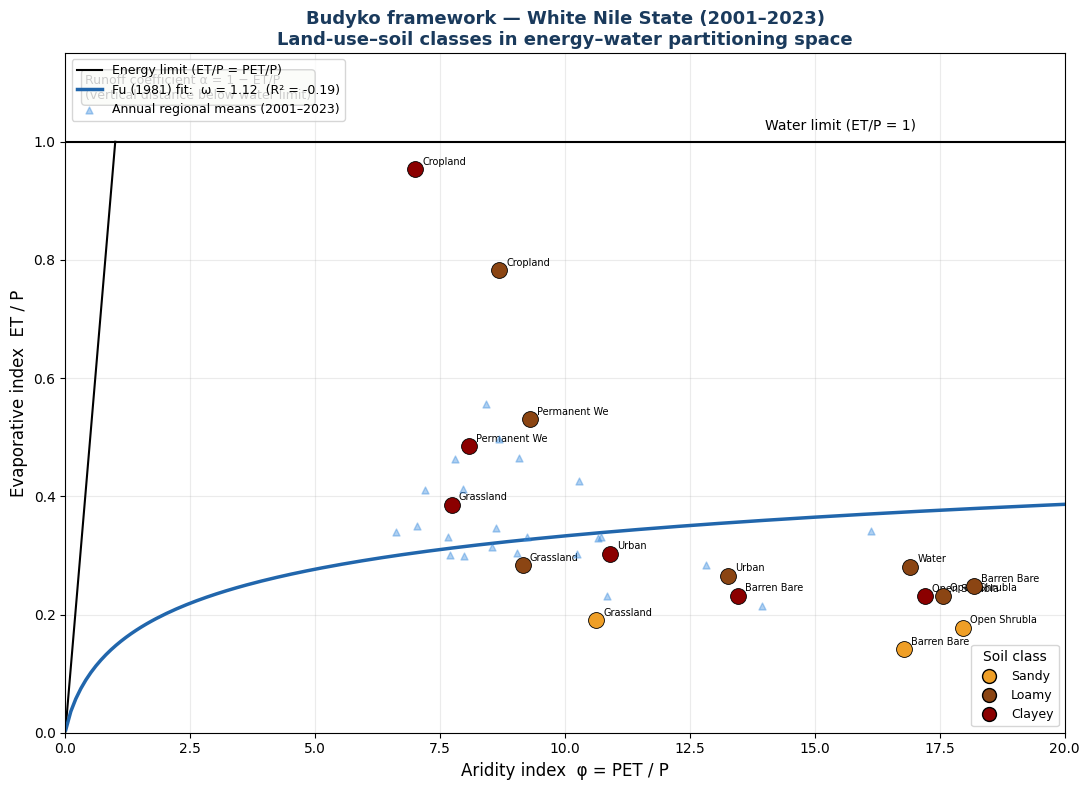

Saved F_Budyko_Framework.png
Export started: RunoffCoefficient_alpha.tif

BUDYKO ANALYSIS SUMMARY
  Fitted Fu parameter ω : 1.124  (R² = -0.190)
  Aridity range φ       : 7.01 – 18.19
  All classes water-limited (φ > 1): True

  Highest runoff coefficient (most water yield):
    Barren_Bare_Soil × Sandy: α = 0.858
  Lowest runoff coefficient (most consumptive):
    Cropland × Clayey: α = 0.046

  Outputs: T9, T10 CSVs + F_Budyko_Framework.png + RunoffCoefficient_alpha.tif


In [ ]:
# =============================================================================
# BUDYKO FRAMEWORK + WATER BALANCE + RUNOFF COEFFICIENT
# White Nile State, Sudan  |  Implements supervisor's revised methodology
#
# Computes, per LULC-Soil class and per year:
#   φ  = PET / P          (aridity / dryness index)
#   EI = ET  / P          (evaporative index)
#   ω                     (Fu 1981 parameter, fitted)
#   α  = R / P = 1 - ET/P (runoff coefficient, long-term)
#
# Produces: Budyko scatter plot, fitted Fu curve, per-class table,
#           annual Budyko trajectory, runoff-coefficient map export.
#
# Paste as a NEW Colab cell. Self-contained.
# =============================================================================

import ee, os, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')

# ── 0. Setup ─────────────────────────────────────────────────────────────────
try:
    ee.Number(1).getInfo()
except Exception:
    ee.Authenticate()
    ee.Initialize(project='evapotranspiration-495110')

OUTPUT_DIR = '/content/drive/MyDrive/ET_WhiteNile_Analysis'
os.makedirs(f'{OUTPUT_DIR}/tables', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots',  exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/geotiff', exist_ok=True)

START_YEAR, END_YEAR = 2001, 2023
START_DATE, END_DATE = f'{START_YEAR}-01-01', f'{END_YEAR}-12-31'
YEARS  = list(range(START_YEAR, END_YEAR + 1))
SCALE  = 500
COMP   = 46   # 8-day composites per year

LULC_CLASSES = {1:'Evergreen_Needleleaf_Forest',2:'Evergreen_Broadleaf_Forest',
    3:'Deciduous_Needleleaf_Forest',4:'Deciduous_Broadleaf_Forest',5:'Mixed_Forest',
    6:'Closed_Shrubland',7:'Open_Shrubland',8:'Woody_Savanna',9:'Savanna',
    10:'Grassland',11:'Permanent_Wetland',12:'Cropland',13:'Urban',
    14:'Cropland_Natural_Mosaic',16:'Barren_Bare_Soil',17:'Water'}
SOIL_CLASSES = {1:'Sandy',2:'Loamy',3:'Clayey'}

# ── 1. AOI ───────────────────────────────────────────────────────────────────
try:
    _ = aoi_geometry.getInfo()
except NameError:
    try:
        AOI = ee.FeatureCollection('projects/ee-abdoyanes2016/assets/White_NILe_State')
        aoi_geometry = AOI.geometry(); aoi_geometry.bounds().getInfo()
        print('AOI: GEE asset')
    except Exception:
        _g = ee.FeatureCollection('FAO/GAUL/2015/level1')
        AOI = _g.filter(ee.Filter.And(ee.Filter.eq('ADM0_NAME','Sudan'),
                                       ee.Filter.eq('ADM1_NAME','White Nile')))
        aoi_geometry = AOI.geometry(); print('AOI: GAUL fallback')

# ── 2. MOD16 (ET + PET) and CHIRPS (P) ──────────────────────────────────────
def _qc(img):
    ok  = img.select('ET_QC').bitwiseAnd(3).lte(1)
    et  = img.select('ET').multiply(0.1).updateMask(ok).rename('ET_mm')
    pet = img.select('PET').multiply(0.1).updateMask(ok).rename('PET_mm')
    return img.addBands(et).addBands(pet).copyProperties(img,['system:time_start'])

MOD16 = (ee.ImageCollection('MODIS/061/MOD16A2GF')
           .filterDate(START_DATE,END_DATE).filterBounds(aoi_geometry).map(_qc))
CHIRPS = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(START_DATE,END_DATE).filterBounds(aoi_geometry))
modis_proj = MOD16.first().select('ET_mm').projection()

# ── 3. LULC + Soil + Combined ────────────────────────────────────────────────
LULC_500m = (ee.ImageCollection('MODIS/061/MCD12Q1')
               .filterDate('2022-01-01','2022-12-31').first()
               .select('LC_Type1').clip(aoi_geometry)
               .reproject(crs=modis_proj,scale=SCALE))
try:
    _sand=ee.Image('ISDASOIL/Africa/v1/sand_content_0_20cm').select('mean_0_20').clip(aoi_geometry)
    _clay=ee.Image('ISDASOIL/Africa/v1/clay_content_0_20cm').select('mean_0_20').clip(aoi_geometry)
    _sand.reduceRegion(ee.Reducer.mean(),aoi_geometry.centroid(30),500,maxPixels=10).getInfo()
    _vm=_sand.mask().And(_clay.mask())
    SOIL_500m=(ee.Image(2).where(_sand.gte(70),1).where(_clay.gte(35),3)
                 .rename('SoilClass').updateMask(_vm).clip(aoi_geometry)
                 .reproject(crs=modis_proj,scale=SCALE))
    print('Soil: iSDAsoil')
except Exception:
    _sand=ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02').expression("(b('b0')+b('b10'))/2")
    _clay=ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02').expression("(b('b0')+b('b10'))/2")
    SOIL_500m=(ee.Image(2).where(_sand.gte(70),1).where(_clay.gte(35),3)
                 .rename('SoilClass').clip(aoi_geometry).reproject(crs=modis_proj,scale=SCALE))
    print('Soil: OpenLandMap')

COMBINED = (LULC_500m.multiply(10).add(SOIL_500m)
              .rename('LULC_Soil_Class').reproject(crs=modis_proj,scale=SCALE))

# ── 4. Long-term mean ET, PET (annual mm) and P ─────────────────────────────
ET_annual  = MOD16.select('ET_mm').mean().multiply(COMP).rename('ET')
PET_annual = MOD16.select('PET_mm').mean().multiply(COMP).rename('PET')

def _annual_P(y):
    return CHIRPS.filter(ee.Filter.calendarRange(y,y,'year')).sum().rename('P')
P_annual = ee.ImageCollection([_annual_P(y) for y in YEARS]).mean().clip(aoi_geometry)

# Stack for per-class extraction
stack = ET_annual.addBands(PET_annual).addBands(P_annual)

# ── 5. Per-class Budyko indices (long-term) ─────────────────────────────────
print('\nComputing Budyko indices per LULC-Soil class...')
freq = COMBINED.reduceRegion(ee.Reducer.frequencyHistogram(),aoi_geometry,
                              SCALE,maxPixels=1e10,bestEffort=True).getInfo()
fkey = list(freq.keys())[0]
codes = sorted([int(float(k)) for k,v in freq[fkey].items()
                if int(float(k))>0 and float(v)>10])

rows=[]
for code in codes:
    lulc, soil = code//10, code%10
    if soil==0: continue
    m = stack.updateMask(COMBINED.eq(int(code))).reduceRegion(
        ee.Reducer.mean(),aoi_geometry,SCALE,maxPixels=1e10,bestEffort=True).getInfo()
    et,pet,p = m.get('ET'),m.get('PET'),m.get('P')
    if not (et and pet and p) or p==0: continue
    phi   = pet/p          # aridity index PET/P
    ei    = et/p           # evaporative index ET/P
    alpha = 1 - ei         # runoff coefficient (long-term)
    rows.append({
        'LULC_Name':LULC_CLASSES.get(lulc,f'C{lulc}'),
        'Soil_Name':SOIL_CLASSES.get(soil,f'S{soil}'),
        'Combo':f'{LULC_CLASSES.get(lulc,lulc)} × {SOIL_CLASSES.get(soil,soil)}',
        'P_mm':round(p,1),'ET_mm':round(et,1),'PET_mm':round(pet,1),
        'Aridity_PET_P':round(phi,3),'Evap_Index_ET_P':round(ei,3),
        'Runoff_Coef_alpha':round(alpha,3),
    })

df = pd.DataFrame(rows).sort_values('Evap_Index_ET_P',ascending=False).reset_index(drop=True)
df.to_csv(f'{OUTPUT_DIR}/tables/T9_Budyko_Indices_by_Class.csv',index=False)
print(f'Saved T9_Budyko_Indices_by_Class.csv ({len(df)} classes)')
print(df[['Combo','Aridity_PET_P','Evap_Index_ET_P','Runoff_Coef_alpha']].to_string(index=False))

# ── 6. Fit Fu (1981) one-parameter Budyko curve ─────────────────────────────
# ET/P = 1 + φ - (1 + φ^ω)^(1/ω)
def fu(phi, omega):
    return 1 + phi - (1 + phi**omega)**(1.0/omega)

phi_obs = df['Aridity_PET_P'].values
ei_obs  = df['Evap_Index_ET_P'].values
try:
    popt,_ = curve_fit(fu, phi_obs, ei_obs, p0=[2.0], bounds=(1.01,10))
    omega_fit = popt[0]
    ei_pred   = fu(phi_obs, omega_fit)
    ss_res    = np.sum((ei_obs-ei_pred)**2)
    ss_tot    = np.sum((ei_obs-ei_obs.mean())**2)
    r2        = 1 - ss_res/ss_tot if ss_tot>0 else np.nan
    print(f'\nFu (1981) fit:  ω = {omega_fit:.3f}   R² = {r2:.3f}')
except Exception as e:
    omega_fit, r2 = 2.6, np.nan
    print(f'Fit failed ({e}); using default ω=2.6')

# ── 7. Annual regional Budyko trajectory ────────────────────────────────────
print('\nComputing annual Budyko trajectory...')
ann=[]
for y in YEARS:
    et = (MOD16.filter(ee.Filter.calendarRange(y,y,'year')).select('ET_mm')
            .mean().multiply(COMP).reduceRegion(ee.Reducer.mean(),aoi_geometry,
            SCALE,maxPixels=1e10,bestEffort=True).getInfo().get('ET_mm'))
    pet= (MOD16.filter(ee.Filter.calendarRange(y,y,'year')).select('PET_mm')
            .mean().multiply(COMP).reduceRegion(ee.Reducer.mean(),aoi_geometry,
            SCALE,maxPixels=1e10,bestEffort=True).getInfo().get('PET_mm'))
    p  = (CHIRPS.filter(ee.Filter.calendarRange(y,y,'year')).sum()
            .reduceRegion(ee.Reducer.mean(),aoi_geometry,5000,
            maxPixels=1e10,bestEffort=True).getInfo().get('precipitation'))
    if et and pet and p and p>0:
        ann.append({'Year':y,'Aridity_PET_P':round(pet/p,3),
                    'Evap_Index_ET_P':round(et/p,3),
                    'Runoff_Coef_alpha':round(1-et/p,3)})
df_ann = pd.DataFrame(ann)
df_ann.to_csv(f'{OUTPUT_DIR}/tables/T10_Budyko_Annual_Trajectory.csv',index=False)
print(f'Saved T10_Budyko_Annual_Trajectory.csv ({len(df_ann)} years)')

# ── 8. FIGURE: Budyko plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11,8))

phi_grid = np.linspace(0.01, max(phi_obs.max(),df_ann['Aridity_PET_P'].max())*1.1, 200)

# Limits
ax.plot([0,1],[0,1],'k-',lw=1.5,label='Energy limit (ET/P = PET/P)')
ax.axhline(1,color='k',ls='-',lw=1.5)
ax.text(phi_grid.max()*0.7,1.02,'Water limit (ET/P = 1)',fontsize=10)

# Fu curve
ax.plot(phi_grid, fu(phi_grid,omega_fit),'-',color='#2166AC',lw=2.5,
        label=f'Fu (1981) fit:  ω = {omega_fit:.2f}  (R² = {r2:.2f})')

# Class points coloured by soil
soil_col={'Sandy':'#EF9F27','Loamy':'#8B4513','Clayey':'#8B0000'}
for _,row in df.iterrows():
    ax.scatter(row['Aridity_PET_P'],row['Evap_Index_ET_P'],
               s=130,c=soil_col.get(row['Soil_Name'],'#888'),
               edgecolors='k',linewidths=0.6,zorder=5)
    ax.annotate(row['LULC_Name'].replace('_',' ')[:12],
                (row['Aridity_PET_P'],row['Evap_Index_ET_P']),
                fontsize=7,xytext=(5,3),textcoords='offset points')

# Annual trajectory (faint)
ax.scatter(df_ann['Aridity_PET_P'],df_ann['Evap_Index_ET_P'],
           s=25,c='#378ADD',alpha=0.4,marker='^',zorder=3,
           label='Annual regional means (2001–2023)')

from matplotlib.lines import Line2D
soil_leg=[Line2D([0],[0],marker='o',color='w',markerfacecolor=v,markeredgecolor='k',
                 markersize=10,label=k) for k,v in soil_col.items()]
leg1=ax.legend(handles=soil_leg,title='Soil class',loc='lower right',fontsize=9)
ax.add_artist(leg1)
ax.legend(loc='upper left',fontsize=9)

ax.set_xlabel('Aridity index  φ = PET / P',fontsize=12)
ax.set_ylabel('Evaporative index  ET / P',fontsize=12)
ax.set_title('Budyko framework — White Nile State (2001–2023)\n'
             'Land-use–soil classes in energy–water partitioning space',
             fontsize=13,fontweight='bold',color='#1A3A5C')
ax.set_xlim(0,phi_grid.max())
ax.set_ylim(0,1.15)
ax.grid(alpha=0.25)
ax.text(0.02,0.97,'Runoff coefficient α = 1 − ET/P\n(vertical distance below water limit)',
        transform=ax.transAxes,fontsize=9,va='top',
        bbox=dict(boxstyle='round',facecolor='#EAF3DE',alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F_Budyko_Framework.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('Saved F_Budyko_Framework.png')

# ── 9. Export runoff coefficient map ────────────────────────────────────────
alpha_map = ee.Image(1).subtract(ET_annual.divide(P_annual)).rename('Runoff_Coef').clip(aoi_geometry)
task = ee.batch.Export.image.toDrive(
    image=alpha_map, description='RunoffCoefficient_alpha',
    folder='ET_WhiteNile_GeoTIFF', fileNamePrefix='RunoffCoefficient_alpha',
    region=aoi_geometry, scale=SCALE, crs='EPSG:4326', maxPixels=1e13)
task.start()
print('Export started: RunoffCoefficient_alpha.tif')

# ── 10. Summary ──────────────────────────────────────────────────────────────
print('\n'+'='*60)
print('BUDYKO ANALYSIS SUMMARY')
print('='*60)
print(f'  Fitted Fu parameter ω : {omega_fit:.3f}  (R² = {r2:.3f})')
print(f'  Aridity range φ       : {df["Aridity_PET_P"].min():.2f} – {df["Aridity_PET_P"].max():.2f}')
print(f'  All classes water-limited (φ > 1): {(df["Aridity_PET_P"]>1).all()}')
print(f'\n  Highest runoff coefficient (most water yield):')
top=df.nlargest(1,'Runoff_Coef_alpha').iloc[0]
print(f'    {top["Combo"]}: α = {top["Runoff_Coef_alpha"]:.3f}')
print(f'  Lowest runoff coefficient (most consumptive):')
bot=df.nsmallest(1,'Runoff_Coef_alpha').iloc[0]
print(f'    {bot["Combo"]}: α = {bot["Runoff_Coef_alpha"]:.3f}')
print(f'\n  Outputs: T9, T10 CSVs + F_Budyko_Framework.png + RunoffCoefficient_alpha.tif')
print('='*60)
